# PyTorch Neural Networks

In [ ]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# Check available hardware
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU is available, using {device}')
elif torch.mps.is_available():
    device = torch.device('mps')
    print(f'Apple Metal Performance Shaders framework is available, using {device}')
else:
    device = torch.device('cpu')
    print(f'Hardware acceleration not available, using {device}')

Apple Metal Performance Shaders framework is available, using mps


## Linear Regression

[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

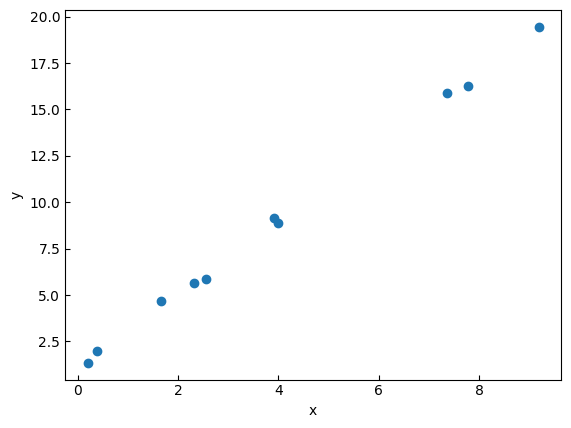

In [16]:
X = np.random.uniform(size=(10, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.25, size=X.shape).astype(np.float32)

y = 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

In [17]:
from torch.utils.data import TensorDataset, DataLoader
X_train = torch.from_numpy(X)
y_train = torch.from_numpy(y)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [40]:
# Initialize the model weights
slope = torch.randn(1)
slope.requires_grad_() # We want to compute gradients for this parameter

intercept = torch.zeros(1, requires_grad=True)

def mse_loss(y_true, y_pred):
    return (y_true - y_pred).pow(2).mean()

def model(x):
    return x @ slope + intercept

lr = 0.01
num_epochs = 100
log_epochs = 10

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = mse_loss(y_batch, y_pred)

        loss.backward() # This computes the gradients for our relevant tensors

        with torch.no_grad(): # We don't track gradients when updating weights now
            slope -= lr * slope.grad
            intercept -= lr * intercept.grad

            slope.grad.zero_()
            intercept.grad.zero_()
        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 20.156
Epoch 10: loss = 1.260
Epoch 20: loss = 0.631
Epoch 30: loss = 0.622
Epoch 40: loss = 0.602
Epoch 50: loss = 0.549
Epoch 60: loss = 0.701
Epoch 70: loss = 0.614
Epoch 80: loss = 0.560
Epoch 90: loss = 1.100


Fit parameters: slope = 2.008, intercept = 1.114


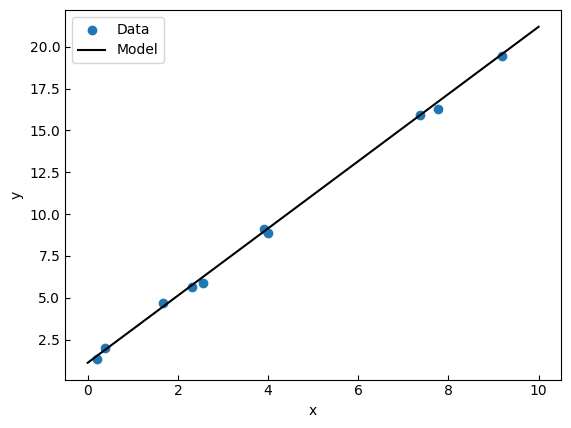

In [41]:
print(f"Fit parameters: slope = {slope.item():.3f}, intercept = {intercept.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

xx = torch.linspace(0, 10, 5, dtype=torch.float32, requires_grad=False)
yy = model(xx[:, None])
ax.plot(xx.numpy(), yy.detach().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

In [46]:
# Initialize the model weights
slope = torch.randn(1, requires_grad=True)
intercept = torch.zeros(1, requires_grad=True)

for x_batch, y_batch in train_loader:
    print(slope.grad, intercept.grad)

    y_pred = model(x_batch)
    print(slope.grad, intercept.grad)

    loss = mse_loss(y_batch, y_pred)
    print(slope.grad, intercept.grad)

    loss.backward() # This computes the gradients for our relevant tensors
    print(slope.grad, intercept.grad)

    break

None None
None None
None None
tensor([-1.3148]) tensor([-3.4851])


In [48]:
# Or we can do this using `torch.nn` and its associated machinery
model = torch.nn.Linear(X_train.shape[1], y_train.shape[0], bias=True).to(device)
loss = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        y_pred = model(x_batch)[:, 0]
        loss = mse_loss(y_batch, y_pred)

        loss.backward() # This computes the gradients for our relevant tensors
        optimizer.step() # Apply the gradient update to parameters
        optimizer.zero_grad() # Reset all gradients

        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 479.323
Epoch 10: loss = 0.889
Epoch 20: loss = 0.729
Epoch 30: loss = 0.716
Epoch 40: loss = 0.680
Epoch 50: loss = 0.536
Epoch 60: loss = 1.134
Epoch 70: loss = 0.844
Epoch 80: loss = 0.613
Epoch 90: loss = 0.822


Fit parameters: slope = 0.700, intercept = 0.000


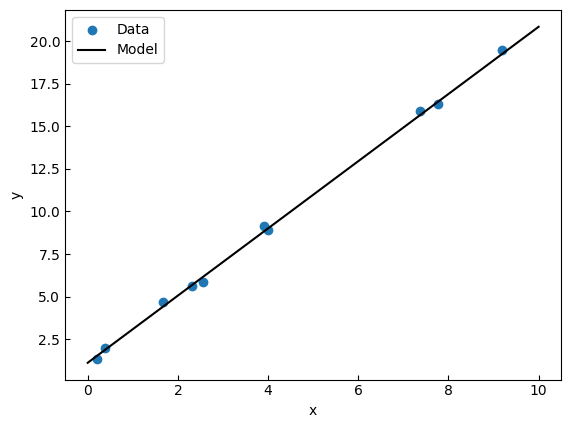

In [53]:
print(f"Fit parameters: slope = {slope.item():.3f}, intercept = {intercept.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

with torch.no_grad():
    xx = torch.linspace(0, 10, 5, dtype=torch.float32, device=device)
    yy = model(xx[:, None])[:, 0]
    ax.plot(xx.cpu().numpy(), yy.cpu().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

## Polynomial Regression

Fit a model with polynomial features to the following dataset using `torch`

[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

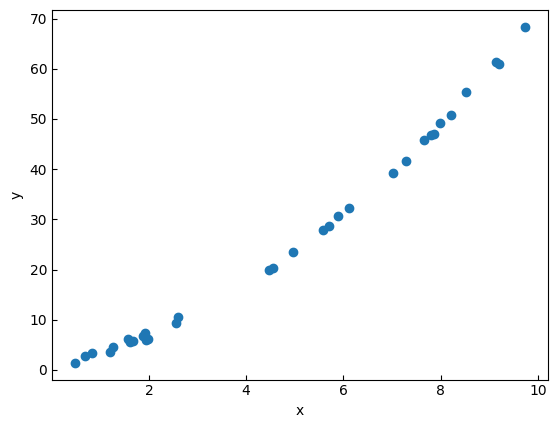

In [56]:
X = np.random.uniform(size=(32, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.5, size=X.shape).astype(np.float32)

y = 0.5 * X**2 + 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

## MLP Classification

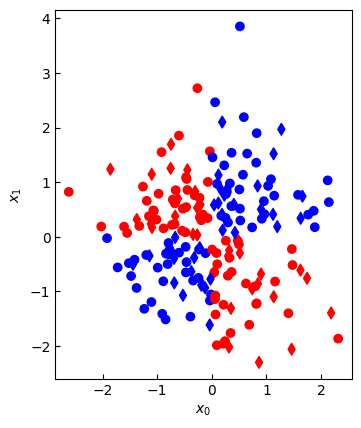

In [119]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.randn(N, 2).astype(np.float32)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X, y = make_xor_dataset(N=128, random_seed=42)
X_test, y_test = make_xor_dataset(N=64, random_seed=1)

ax = plt.figure().gca()
ax.scatter(X[:, 0], X[:, 1], c=y, marker='o', cmap='bwr')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='d', cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal');

In [120]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
train_dataset, val_dataset = random_split(dataset, (0.8, 0.2))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

Train: 103, Val: 25, Test: 64


In [147]:
class Model(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.sigmoid(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

Model(
  (hidden_layer): Linear(in_features=2, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=2, bias=True)
)

In [148]:
def train(model, loss_fn, optimizer, train_loader, val_loader, max_epochs=500):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    for epoch in range(max_epochs):
        train_loss.append(0)
        train_acc.append(0)
        for x, y, in train_loader:
            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss[-1] += loss.item() * x.shape[0]
            train_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss[-1] /= len(train_dataset)
        train_acc[-1] /= len(train_dataset)

        val_loss.append(0)
        val_acc.append(0)
        with torch.no_grad():
            for x, y, in val_loader:
                x = x.to(device)
                y = y.to(device)

                y_pred = model(x)
                loss = loss_fn(y_pred, y)

                val_loss[-1] += loss.item() * x.shape[0]
                val_acc[-1]  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss[-1] /= len(val_dataset)
            val_acc[-1] /= len(val_dataset)

    return model, (train_loss, train_acc, val_loss, val_acc)

model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)

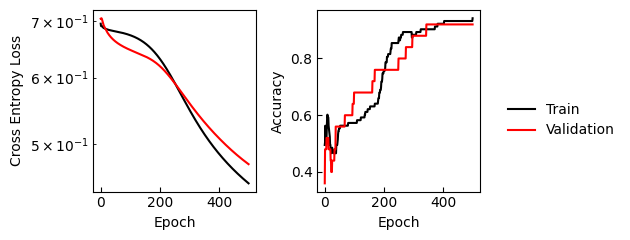

In [149]:
def loss_accuracy_plot(train_loss, train_acc, val_loss, val_acc):
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

    ax[0].plot(train_loss, color='black', label='Train')
    ax[0].plot(val_loss, color='red', label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Cross Entropy Loss', yscale='log')

    ax[1].plot(train_acc, color='black', label='Train')
    ax[1].plot(val_acc, color='red', label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Accuracy')

    fig.legend(*ax[1].get_legend_handles_labels(), 
            loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
    return fig

loss_accuracy_plot(*model_stats)
plt.tight_layout()

<Axes: >

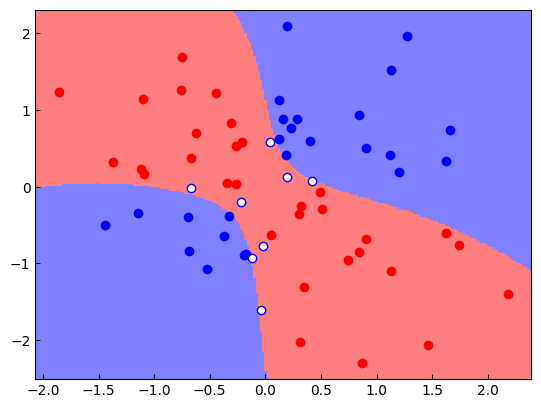

In [150]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    with torch.no_grad():
        x_grid = np.stack([x1.ravel(), x2.ravel()]).T
        x_grid = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        y_model = model(x_grid).cpu().numpy()
        y_model = np.argmax(y_model, axis=-1)
        y_model = y_model.reshape(x1.shape)

        y_pred = model(torch.from_numpy(X).to(device)).cpu().numpy()
        y_pred = np.argmax(y_pred, axis=1)

        pred_mask = y_pred == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Deep MLP example

In [152]:
class Model(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer1 = torch.nn.Linear(input_size, hidden_size)
        self.hidden_layer2 = torch.nn.Linear(hidden_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer1(x)
        x = torch.nn.functional.sigmoid(x)
        x = self.hidden_layer2(x)
        x = torch.nn.functional.sigmoid(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

Model(
  (hidden_layer1): Linear(in_features=2, out_features=128, bias=True)
  (hidden_layer2): Linear(in_features=128, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=2, bias=True)
)

<Axes: >

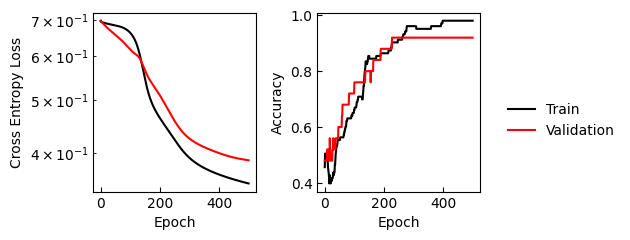

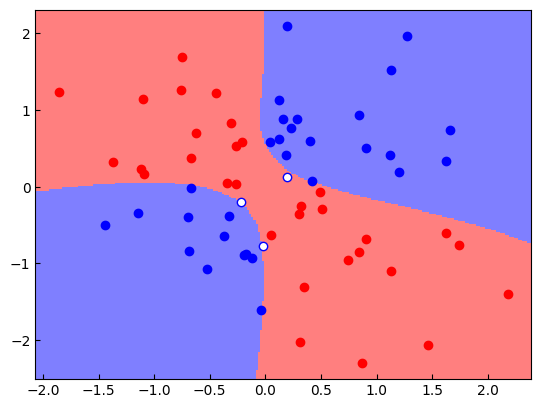

In [153]:
model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Activation functions

In [154]:
class LinearModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

class TanhModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.tanh(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

class ReLUModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(input_size, hidden_size)
        self.output_layer = torch.nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden_layer(x)
        x = torch.nn.functional.relu(x)
        x = self.output_layer(x)
        x = torch.nn.functional.softmax(x, dim=1)
        return x

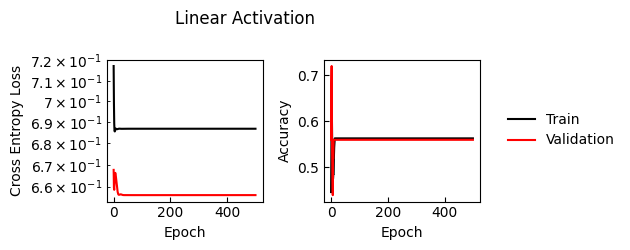

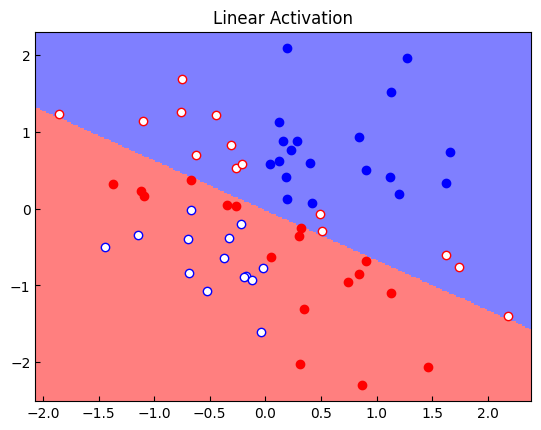

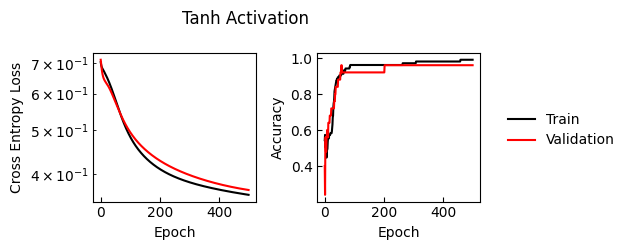

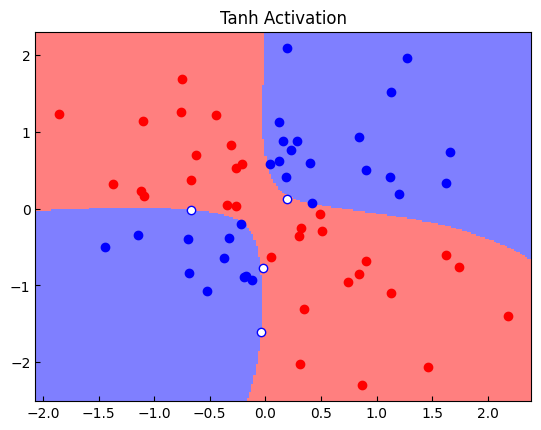

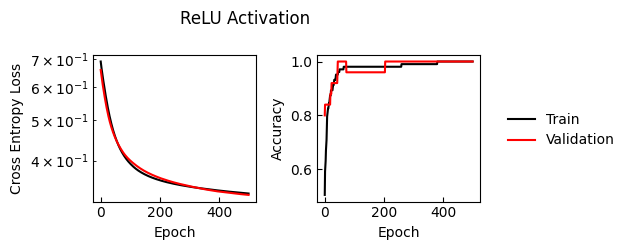

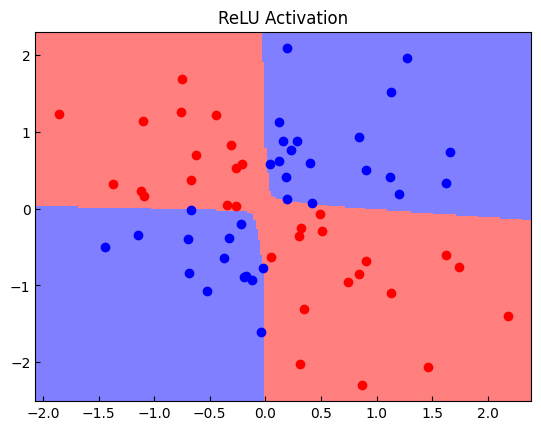

In [155]:
for label, model_type in zip(['Linear', 'Tanh', 'ReLU'],
                             [LinearModel, TanhModel, ReLUModel]):
    model = model_type(
        input_size=X.shape[1],
        hidden_size=128,
        output_size=2, # 2 classes
    ).to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)
    fig = loss_accuracy_plot(*model_stats)
    fig.suptitle(label + " Activation")
    plt.tight_layout()

    ax = plt.figure().gca()
    plot_decision_boundary(ax, X_test, y_test, model)
    ax.set_title(label + " Activation")
    plt.show()